In [1]:
import yaml, json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from analysis_configs import eval_colors_list, legend_kwargs

# Set Seaborn style for better looking plots
sns.set_theme(style="whitegrid")
sns.set_palette("colorblind")  # More accessible color palette
# Import configurations from default_configs.py
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',  # More formal for academic papers
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 22,
    'figure.figsize': (10, 6),  # Good size for single-column papers
    'lines.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.3
})

def results_by_env_to_df_row(filepath, directory):
    # If the file is a json, load it as a json
    full_path = os.path.join(directory, filepath)
    if full_path.endswith(".json"):
        data = json.load(open(full_path))
    elif full_path.endswith(".yaml"):
        data = yaml.safe_load(open(full_path))
    else:
        raise ValueError(f"Unsupported file type, require .json or .yaml: {full_path}")

    # Extract job ID from log files in the same directory
    dir_path = os.path.dirname(full_path)
    job_id = None
    if os.path.exists(dir_path):
        log_files = [f for f in os.listdir(dir_path) if f.startswith('eval_llm_') and f.endswith('.out')]
        if log_files:
            job_id = log_files[0].replace('eval_llm_', '').replace('.out', '')

    for eval, results in data.items():
        row = {'name': filepath, 'env': eval, 'job_id': job_id}
        for key, value in results.items():
            row[key] = value
        yield row



In [8]:
# read .json files from subdirs of the current dir
import os
import numpy as np

evals_dir = "data/full_llm_evals"
subdirs = [f for f in os.listdir(evals_dir) if os.path.isdir(os.path.join(evals_dir, f))]
filepaths = [os.path.join(subdir, f) for subdir in subdirs for f in os.listdir(os.path.join(evals_dir, subdir)) if f.endswith(".json")]

# Job ID to GPU mapping based on the user's commands
job_gpu_mapping = {
    # FS_PPO on swarm_l4 (L4 GPUs) - jobs 344292, 344293, 344294
    '344292': 'L4', '344293': 'L4', '344294': 'L4',
    # FS_PPO on l40 (L40 GPUs) - jobs 344295, 344296, 344297
    '344295': 'L40', '344296': 'L40', '344297': 'L40',
    # FL_PPO on swarm_l4 (L4 GPUs) - jobs 344298, 344299, 344300
    '344298': 'L4', '344299': 'L4', '344300': 'L4',
    # FL_PPO on l40 (L40 GPUs) - jobs 344301, 344302, 344303
    '344301': 'L40', '344302': 'L40', '344303': 'L40',
}

# Load all data first
data = []
for filepath in filepaths:
    for row in results_by_env_to_df_row(filepath, evals_dir):
        data.append(row)

df_raw = pd.DataFrame(data)
print(f"Total raw data points: {len(df_raw)}")

# Add derived columns
df_raw['tokens_per_rollout'] = df_raw['total_tokens_generated'] / df_raw['number_of_episodes']
df_raw['inference_time_per_rollout'] = df_raw['time_taken'] / df_raw['number_of_episodes']

print(df_raw['name'].unique())
# Extract model configuration from folder names
names = df_raw['name'].str.split('/').str[0]
print(names.unique())
df_raw['model_size'] = names.str.split('_').str[0].str.split('-').str[1]
print(df_raw['model_size'].unique())
df_raw['is_4096'] = names.str.split('_').str[3] == '4096'
df_raw['is_cot'] = names.str.split('_').str[4] == 'cot'

# Map job IDs to GPU types
df_raw['gpu_type'] = df_raw['job_id'].map(job_gpu_mapping).fillna('H100')  # Default to H100 for older runs

# Group by model configuration and calculate statistics
grouped_data = []
for (model_size, is_4096, is_cot, env, gpu_type), group in df_raw.groupby(['model_size', 'is_4096', 'is_cot', 'env', 'gpu_type']):
    # Calculate statistics for each metric
    stats = {
        'model_size': model_size,
        'is_4096': is_4096,
        'is_cot': is_cot,
        'env': env,
        'gpu_type': gpu_type,
        'n_runs': len(group),
        
        # Mean scores
        'mean_score': group['mean_score'].mean(),
        'mean_score_std': group['mean_score'].std(),
        'mean_score_sem': group['mean_score'].std() / np.sqrt(len(group)),

        'mean_reward': group['mean_reward'].mean(),
        
        # Time metrics
        'time_taken': group['time_taken'].mean(),
        'time_taken_std': group['time_taken'].std(),
        'time_taken_sem': group['time_taken'].std() / np.sqrt(len(group)),
        
        'inference_time_per_rollout': group['inference_time_per_rollout'].mean(),
        'inference_time_per_rollout_std': group['inference_time_per_rollout'].std(),
        'inference_time_per_rollout_sem': group['inference_time_per_rollout'].std() / np.sqrt(len(group)),
        
        # Token metrics
        'tokens_per_rollout': group['tokens_per_rollout'].mean(),
        'tokens_per_rollout_std': group['tokens_per_rollout'].std(),
        'tokens_per_rollout_sem': group['tokens_per_rollout'].std() / np.sqrt(len(group)),
        
        # Other metrics
        'mean_episode_length': group['mean_episode_length'].mean(),
        'mean_episode_length_std': group['mean_episode_length'].std(),
        'mean_episode_length_sem': group['mean_episode_length'].std() / np.sqrt(len(group)),
    }
    grouped_data.append(stats)

# Create the final dataframe with grouped statistics
df = pd.DataFrame(grouped_data)
print(f"Grouped data points: {len(df)}")
print(f"Number of runs per group: {df['n_runs'].value_counts().sort_index()}")

# Show some examples of the grouping
print("\nExample groupings:")
print(df[['model_size', 'is_4096', 'is_cot', 'env', 'n_runs']].head(10))

Total raw data points: 97
['FS_PPO_7B_run41_600_converted_aamas_evals_20251015_150220/eval_results.json'
 'Qwen2.5-7B-Instruct_aamas_evals_4096_cot_20251015_175100/eval_results.json'
 'FS-FSPPO7B_run41_600_converted_aamas_evals_20251015_150220/eval_results.json'
 'snakebench_job_lr1em05_eps100000_g0p9_155795/eval_results.json'
 'FS-FSPPO3B_run12_600_converted_aamas_evals_20251008_130944/eval_results.json'
 'Qwen2.5-14B-Instruct_aamas_evals_4096_cot_20251015_175100/eval_results.json'
 'Qwen2.5-72B-Instruct_aamas_evals_4096_cot_20251007_084814/eval_results.json'
 'FS_PPO_14B_run1_1200_converted_aamas_evals_20251015_150220/eval_results.json'
 'FS_PPO_3B_run12_600_converted_aamas_evals_20251008_130944/eval_results.json'
 'Qwen2.5-72B-Instruct_aamas_evals_20251007_084815/eval_results.json'
 'Qwen2.5-14B-Instruct_aamas_evals_20251015_175100/eval_results.json'
 'Qwen2.5-32B-Instruct_aamas_evals_4096_cot_20251007_084825/eval_results.json'
 'Qwen2.5-7B-Instruct_aamas_evals_20251015_175100/eval_


=== FastSnake-20Steps: Inference Time per Rollout vs Mean Score ===
Saved chart to: charts/Snake_20Step_inference_time.png


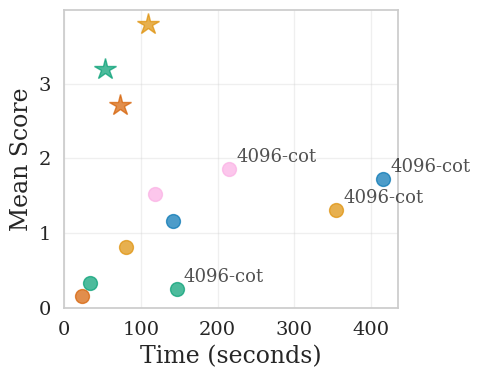

,model_size,is_4096,is_cot,env,gpu_type,n_runs,mean_score,mean_score_std,mean_score_sem,mean_reward,...,inference_time_per_rollout,inference_time_per_rollout_std,inference_time_per_rollout_sem,tokens_per_rollout,tokens_per_rollout_std,tokens_per_rollout_sem,mean_episode_length,mean_episode_length_std,mean_episode_length_sem,label
4,14B,False,False,Snake-20Step,H100,1,0.8217,NaN,NaN,-0.8478,...,0.810442,NaN,NaN,1171.99,NaN,NaN,9.780000,NaN,NaN,256
10,14B,True,True,Snake-20Step,H100,1,1.3167,NaN,NaN,-0.4531,...,3.546479,NaN,NaN,2929.11,NaN,NaN,10.309999,NaN,NaN,4096-cot
16,32B,False,False,Snake-20Step,H100,1,1.5246,NaN,NaN,-0.2383,...,1.185984,NaN,NaN,1379.20,NaN,NaN,9.830000,NaN,NaN,256
22,32B,True,True,Snake-20Step,H100,1,1.8612,NaN,NaN,0.0509,...,2.151916,NaN,NaN,2614.93,NaN,NaN,10.910000,NaN,NaN,4096-cot
28,3B,False,False,Snake-20Step,H100,1,0.1683,NaN,NaN,-1.8496,...,0.235321,NaN,NaN,645.58,NaN,NaN,5.960000,NaN,NaN,256
34,72B,False,False,Snake-20Step,H100,1,1.1682,NaN,NaN,-0.7237,...,1.424225,NaN,NaN,1006.33,NaN,NaN,8.370000,NaN,NaN,256
40,72B,True,True,Snake-20Step,H100,1,1.7325,NaN,NaN,-0.0871,...,4.159476,NaN,NaN,3258.56,NaN,NaN,9.710000,NaN,NaN,4096-cot
46,7B,False,False,Snake-20Step,H100,1,0.3366,NaN,NaN,-1.5873,...,0.342325,NaN,NaN,706.59,NaN,NaN,6.730000,NaN,NaN,256
52,7B,True,True,Snake-20Step,H100,1,0.2574,NaN,NaN,-1.6436,...,1.466366,NaN,NaN,2624.41,NaN,NaN,8.360000,NaN,NaN,4096-cot
58,FSPPO14B,False,False,Snake-20Step,H100,1,3.8016,NaN,NaN,2.7722,...,1.089973,NaN,NaN,2149.07,NaN,NaN,14.780000,NaN,NaN,256


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Define color scheme based on model size
size_colors = {
    '0.5B': '#949494',  # Grey
    '3B': '#D55E00',    # Orange  
    '7B': '#029E73',    # Green
    '14B': '#DE8F05',   # Yellow/Orange
    '32B': '#FBAFE4',   # Pink
    '72B': '#0173B2',   # Blue
    'Unknown': '#000000' # Black fallback
}

# Function to extract base model size from model name (including PPO variants)
def get_base_model_size(model_size):
    """Extract the base model size from any model name, including PPO variants."""
    # Handle PPO variants like '3BFSPPO', '3BFLPPO', 'FSPPO3B', etc.
    if 'PPO' in model_size:
        # Extract the numeric part followed by 'B'
        import re
        match = re.search(r'(\d+\.?\d*)B', model_size)
        if match:
            return f"{match.group(1)}B"
    return model_size

# Create labels in the format {model_size}-{4096/256}(-cot)
def create_label(row):
    model_size = row['model_size']
    context_size = '4096' if row['is_4096'] else '256'
    cot_suffix = '-cot' if row['is_cot'] else ''
    return f"{context_size}{cot_suffix}"

# Create a function to plot scatter charts with error bars
def create_scatter_plot(env_name, x_metric, x_label, title_suffix):
    # Filter data for the environment
    env_data = df[df['env'] == env_name].copy()
    
    # Filter: For 0.5B, 3B, and PPO models, only use 256 context size (not 4096)
    env_data = env_data[~((env_data['model_size'].isin(['0.5B', '3B', '3BFSPPO', '3BFLPPO'])) & env_data['is_4096'])]
    
    # Filter: Remove PPO models from environments they weren't trained on
    if 'Snake' in env_name:
        # Remove FLPPO models from Snake environments
        env_data = env_data[~env_data['model_size'].str.contains('FLPPO', na=False)]
    elif 'FrozenLake' in env_name:
        # Remove FSPPO models from FrozenLake environments
        env_data = env_data[~env_data['model_size'].str.contains('FSPPO', na=False)]
    
    env_data['label'] = env_data.apply(create_label, axis=1)
    
    # Create the plot
    plt.figure(figsize=(5, 4))
    
    # GPU information mapping
    gpu_info = {
        '0.5B': '1x H100',
        '3B': '1x H100', 
        '7B': '1x H100',
        '14B': '1x H100',
        '32B': '2x H100',
        '72B': '4x H100',
        '3BFSPPO': '1x H100',
        '3BFLPPO': '1x H100',
        'FSPPO3B': '1x H100',
        'FSPPO7B': '1x H100',
        'FSPPO14B': '1x H100',
    }
    
    # Define model size order (PPO models first, then ascending by size)
    def get_model_order(model_size):
        if model_size in ['3BFSPPO', '3BFLPPO', 'FSPPO3B', 'FSPPO7B', 'FSPPO14B']:
            return (0, model_size)  # PPO models first
        else:
            # Extract numeric size for ordering
            size_num = float(model_size.replace('B', ''))
            return (1, size_num)  # Regular models ordered by size
    
    # Sort model sizes for consistent legend ordering
    sorted_model_sizes = sorted(env_data['model_size'].unique(), key=get_model_order)
    
    # Plot points with error bars for different model sizes
    for i, model_size in enumerate(sorted_model_sizes):
        model_data = env_data[env_data['model_size'] == model_size]
        
        # Get color based on base model size
        base_size = get_base_model_size(model_size)
        color = size_colors.get(base_size, size_colors['Unknown'])
        
        # Use star marker for PPO models
        posttrained_models = ['3BFSPPO', '3BFLPPO', 'FSPPO3B', 'FSPPO7B', 'FSPPO14B']
        marker = '*' if model_size in posttrained_models else 'o'
        size = 16 if model_size in posttrained_models else 10
        
        # Create label with GPU info
        gpu = gpu_info.get(model_size, 'Unknown GPU')
        
        # Custom labels for PPO models
        if model_size == '3BFSPPO':
            display_name = '3B PPO'
        elif model_size == '3BFLPPO':
            display_name = '3B FL PPO'
        elif model_size == 'FSPPO3B':
            display_name = '3B PPO'
        elif model_size == 'FSPPO7B':
            display_name = '7B PPO'
        elif model_size == 'FSPPO14B':
            display_name = '14B PPO'
        else:
            display_name = model_size
            
        label = f'{display_name} ({gpu})'
        
        # Plot with error bars but no connecting lines
        plt.errorbar(model_data[x_metric], 
                    model_data['mean_score'],
                    # xerr=model_data[f'{x_metric}_sem'] if f'{x_metric}_sem' in model_data.columns else None,
                    # yerr=model_data['mean_score_sem'],
                    c=color, 
                    marker=marker,
                    markersize=size,  # Larger marker size
                    alpha=0.7,
                    capsize=3,
                    capthick=1.5,
                    elinewidth=1.5,
                    linestyle='none',  # Remove connecting lines
                    label='')  # No label - we'll create legend manually
        
        # Add labels for each point (only for non-256 context)
        for j, row in model_data.iterrows():
            if row['label'] == '256':
                continue
            plt.annotate(row['label'], 
                        (row[x_metric], row['mean_score']),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=13, alpha=0.8)
    
    # Create custom legend with 2 columns: model sizes in col 1, marker styles in col 2
    # GPU info by base model size
    base_gpu_info = {
        '0.5B': '1x H100',
        '3B': '1x H100', 
        '7B': '1x H100',
        '14B': '1x H100',
        '32B': '2x H100',
        '72B': '4x H100',
    }
    
    # Get unique base model sizes present in the data
    unique_base_sizes = sorted(set(get_base_model_size(ms) for ms in sorted_model_sizes), 
                                key=lambda x: float(x.replace('B', '')))
    
    # Create model size handles and labels
    model_handles = []
    model_labels = []
    for base_size in unique_base_sizes:
        color = size_colors.get(base_size, size_colors['Unknown'])
        gpu = base_gpu_info.get(base_size, 'Unknown GPU')
        handle = plt.Line2D([0], [0], marker='o', color='w', 
                           markerfacecolor=color, markersize=10, alpha=0.7,
                           linestyle='none')
        model_handles.append(handle)
        model_labels.append(f'{base_size} ({gpu})')
    
    # Create marker style handles and labels (gray symbols)
    marker_handles = []
    marker_labels = []
    
    # Base model (dot)
    base_handle = plt.Line2D([0], [0], marker='o', color='w', 
                            markerfacecolor='lightgray', markersize=10, alpha=0.9,
                            linestyle='none')
    marker_handles.append(base_handle)
    marker_labels.append('Base')
    
    # Post-trained model (star)
    posttrained_handle = plt.Line2D([0], [0], marker='*', color='w', 
                                    markerfacecolor='lightgray', markersize=15, alpha=0.9,
                                    linestyle='none')
    marker_handles.append(posttrained_handle)
    marker_labels.append('Post-trained')
    
    # Organize handles and labels for 2-column layout
    # All model sizes go in column 1, then all marker styles in column 2
    legend_handles = model_handles + marker_handles
    legend_labels = model_labels + marker_labels
    
    plt.ylim(bottom=0)  # Set y-axis minimum to 0 while keeping auto maximum
    plt.xlim(left=0)  # Set x-axis minimum to 0 while keeping auto maximum
    plt.xlabel(x_label, fontsize=17)
    plt.ylabel('Mean Score', fontsize=17)
    # plt.title(f'{title_suffix}', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Position legend below the chart with 2 columns
    # plt.legend(legend_handles, legend_labels, 
    #            loc='upper center', 
    #            bbox_to_anchor=(0.5, -0.15),
    #            ncol=2,
    #            frameon=legend_kwargs.get('frameon', True),
    #            framealpha=legend_kwargs.get('framealpha', 0.95),
    #            edgecolor=legend_kwargs.get('edgecolor', 'lightgray'))
    plt.tight_layout()
    
    # Save inference time charts to analysis/charts directory
    if 'time' in x_label.lower() or 'inference' in x_label.lower():
        import os
        os.makedirs('charts', exist_ok=True)
        
        # Create filename from environment and metric
        env_clean = env_name.replace('-', '_').replace(' ', '_')
        filename = f'{env_clean}_inference_time.png'
        filepath = f'charts/{filename}'
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Saved chart to: {filepath}")
    
    plt.show()
    
    return env_data

# Create all 4 charts
# print("=== FastSnake-20Steps: Tokens per Rollout vs Mean Score ===")
# fastsnake_tokens = create_scatter_plot('Snake-20Step', 'tokens_per_rollout', 'Tokens per Rollout', 'Snake, 20 Steps')

print("\n=== FastSnake-20Steps: Inference Time per Rollout vs Mean Score ===")
fastsnake_time = create_scatter_plot('Snake-20Step', 'time_taken', 'Time (seconds)', 'Snake, 20 Steps')

# print("=== FastSnake-Default: Tokens per Rollout vs Mean Score ===")
# fastsnake_tokens = create_scatter_plot('FastSnake-Default', 'tokens_per_rollout', 'Tokens per Rollout', 'Snake, 8 Steps')

# print("\n=== FastSnake-Default: Inference Time per Rollout vs Mean Score ===")
# fastsnake_time = create_scatter_plot('FastSnake-Default', 'time_taken', 'Time (seconds)', 'Snake, 8 Steps')

# # print("\n=== FrozenLake-NoSlip: Tokens per Rollout vs Mean Score ===")
# # frozenlake_tokens = create_scatter_plot('FrozenLake-NoSlip', 'tokens_per_rollout', 'Tokens per Rollout', 'Frozen Lake, No Slip')

# print("\n=== FrozenLake-NoSlip: Inference Time per Rollout vs Mean Score ===")
# frozenlake_time = create_scatter_plot('FrozenLake-NoSlip', 'time_taken', 'Time (seconds)', 'Frozen Lake, No Slip')

# # print("\n=== FrozenLake-Slippery: Tokens per Rollout vs Mean Score ===")
# # frozenlake_tokens = create_scatter_plot('FrozenLake-Slippery', 'tokens_per_rollout', 'Tokens per Rollout', 'Frozen Lake, Slippery')

# print("\n=== FrozenLake-Slippery: Inference Time per Rollout vs Mean Score ===")
# frozenlake_time = create_scatter_plot('FrozenLake-Slippery', 'time_taken', 'Time (seconds)', 'Frozen Lake, Slippery')
fastsnake_time